# Natural Language Processing (NLP) / Generative AI R&D
## SLP Survey 
### Data Processing (Generative Query)

Read inputs from a MS Forms survey and perform:

+ Sentiment Analysis and Sentiment Confidence
+ Categorization
+ All comments Word Cloud
+ All comments Summarization

Output presented to Power BI dashboard.

### Version History
+ v0.1 - Initial prototype, minimal to no data cleansing, inside source and reviewed by HITL.
+ v0.2 - Fixed issue with dataframe not updating with sentiment, category after looping.
+ v0.3 - Updated input to include all data in the row plus comments and then a just comments section to the output.
+ v0.4 - Cleaned code with execution for customer review.
+ v0.5 - Updated domain of categories, updated prompt to give context, stop words/lemmatization/stem words applied to comments.
    + Use Stop Word, Lemmatization on totality of comments for Word Cloud generation.
    + Use new categories to build a World cloud based on frequency of use (from rows of data with comments, concatenate all categories from each row and build World Cloud).
    + Update categories (feeding word cloud) and re-run analysis on each row.
    + All data analysis should be with just comments.
    + Update context of Prompt to include USFS values, requestor role, and how the AI should treat analysis of the data.
+ v0.6 - Prompt updated for summarization task and removed lemmatization of aggregated text.
+ v0.7 - Updated prompt categories based on end-user input.  Changed input file required and output to match versioning for initial DVC standard.


### TODO
+ None

### Privacy Information

No action taken.

### Prompt Injection Defense

No action taken.

### References:


### Technical References

### Jupyte Notebook Hints
https://jupyter-tutorial.readthedocs.io/en/24.1.0/notebook/shortcuts.html

In [238]:
# -*- coding: utf-8 -*-

### Environment Validation

Using GCP or Azure read in arrays representing minimal library requirements (which might not be present in a Google Colab environment) and install / load the libraries as required.  Additional imports for standard libraries and tailored content to follow.

In [239]:
#specific libraries like cudf and GPU enabled libs will not load via typical pip install efforts.
#use anaconda to install those capabilities into you env within the kernel you're using
#For CUDF within the desired Anaconda environment:
#    conda install -c rapidsai -c conda-forge -c nvidia rapids=24.06 

###########################################
#- Minimal imports to start
###########################################
try:
    import sys
    import subprocess
    import importlib.util
    import atexit
except ImportError as e:
    print("There was a problem importing the most basic libraries necessary for this code.")
    print(repr(e))
    raise SystemExit("Stop right there!")

###########################################
#- Final Exit Routine
###########################################
@atexit.register
def goodbye():
    print("GOODBYE")

###########################################
#- Cloud Environment Setup (Priming)
###########################################
# variables establishing environments
ENV_GCP=0
ENV_AZURE=1
user_input=-1
environments=["GCP", "Azure"]
    
#prompt user for environment before continuing
user_input = 0
while True:
  try:
     if user_input > -1:
         break;
     user_input = int(input("Select the environment you're running: (0) GCP (1) Azure"))     
     if user_input > 1:
         print("Not a valid choice, please try again.")
         continue;
  except ValueError:
     print("Not a valid choice, please try again.")
     continue
  else:
     print(f"Environment selected is: {environments[user_input]}")
     break 
        
############################################
#- Import a custom library, in this case a fairly useful logging framework
############################################
from pathlib import Path
debug_lib_location = Path("../ML-Support")
sys.path.append(str(debug_lib_location))
try:
  import debug
  debug.msg_debug("...debug library loaded.")
except ImportError as e:
  print("There was a problem importing the debug library.")
  print(repr(e))
  raise SystemExit("Without the debug logging library, this code will not run.")

libraries=["transformers", "langchain", "openpyxl", "python-dotenv", "gensim", 
           "alive-progress", "tqdm", "pyspellchecker", "wordcloud", "langchain", "icecream", "numba", 
           "fitz","dataclasses", "commonregex", "transformers", "spacy", "PyMuPDF", "PyPDF2", "pdfminer", 
           "pdfplumber","pdf2image","pytesseract", "cupy" ]    
debug.msg_info(f"Validating environment for the following pip packages: {libraries}")

#load environment for non-generative libraries
try:
    for library in libraries:
      if library == "Pillow":
        spec = importlib.util.find_spec("PIL")
      else:
        spec = importlib.util.find_spec(library)
      if spec is None:
        print("...installing library " + library)
        subprocess.run(["pip", "install" , library, "--quiet"])
      else:
        print("...library " + library + " already installed.")
except (subprocess.CalledProcessError, Exception) as e:
    print("Error: Failed to install required packages, your code might not run properly.")
    print(repr(e))

#load environment specific libraries for generative AI.
try:    
    if environments[user_input]=="GCP":
      subprocess.run(["pip", "install" , "--upgrade", "google-cloud-aiplatform", "--quiet"])
      subprocess.run(["pip", "install" , "--upgrade", "google-cloud-secret-manager", "--quiet"])
      gcp_libraries=["google-generativeai","google.protobuf", "google.generativeai", "google.cloud.aiplatform_v1beta1",]
      for library in gcp_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    
        from google.cloud import aiplatform
        import vertexai.preview
        import vertexai
        import openai
        from google.auth import default, transport
        from google.cloud import secretmanager
        import google.generativeai as genai
        from vertexai.preview.generative_models import GenerativeModel
        from vertexai.preview.generative_models import GenerationConfig
        from google.cloud.aiplatform_v1beta1.types.openapi import Schema
        from google.cloud.aiplatform_v1beta1.types.openapi import Type
        from google.protobuf.json_format import MessageToDict        
        
          
    elif environments[user_input]=="Azure":
      azure_libraries=["openai", ]
      for library in azure_libraries:
        spec = importlib.util.find_spec(library)
        if spec is None:
          print("...installing library " + library)
          print("...installing library " + library)
          try:
              subprocess.run(["pip", "install" , library, "--quiet"])
          except (subprocess.CalledProcessError, Exception) as e:
              print("Error: Failed to install required packages, your code might not run properly.")
              print(repr(e))
        else:
          print("...library " + library + " already installed.")
    else:
        print("There was a problem processing your request.  Only numeric input of 0 or 1 is allowed.")
        print("Continued operations is not possible without the proper installed tools.")
        raise SystemExit("Stop right there!")
except Exception as e:
    print("There was a problem processing library installs for Generative AI libraries")
    print(repr(e))
    raise SystemExit("Stop right there!")

debug.msg_debug("...dynamic environment installs complete.")

[2024-11-18 16:18:42 UTC]   DEBUG: ...debug library loaded. 
[2024-11-18 16:18:42 UTC]    INFO: Validating environment for the following pip packages: ['transformers', 'langchain', 'openpyxl', 'python-dotenv', 'gensim', 'alive-progress', 'tqdm', 'pyspellchecker', 'wordcloud', 'langchain', 'icecream', 'numba', 'fitz', 'dataclasses', 'commonregex', 'transformers', 'spacy', 'PyMuPDF', 'PyPDF2', 'pdfminer', 'pdfplumber', 'pdf2image', 'pytesseract', 'cupy'] 
...library transformers already installed.
...library langchain already installed.
...library openpyxl already installed.
...installing library python-dotenv
...library gensim already installed.
...installing library alive-progress
...library tqdm already installed.
...installing library pyspellchecker
...library wordcloud already installed.
...library langchain already installed.
...library icecream already installed.
...library numba already installed.
...library fitz already installed.
...library dataclasses already installed.
...lib

### Additional Libraries

Read in core libraries, local logging framework, data science tools, Natural Language Processing Toolkit (NLTK), Spacy and other tools to support the effort.

In [240]:
debug.msg_info("Library imports")    
############################################
# INCLUDES
############################################

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# a set of libraries that perhaps should always be in Python source
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...core libraries.")
import os
import datetime
import gc
import socket
import sys
import getopt
import inspect
import traceback
import warnings
import json
import pickle
from pathlib import Path
import itertools
import datetime
import re
import shutil
import string
from io import StringIO
import tqdm


import io
import math
import textwrap
import random
import glob
import time
from time import perf_counter
import subprocess
from multiprocessing import Pool
import backoff                    #annotation to support repeat calls on api failure

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Function Profiling
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
import cProfile
import pstats
import io
from pstats import SortKey

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# MS Excel Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
from openpyxl import Workbook
from openpyxl.utils import get_column_letter
from openpyxl.styles import PatternFill, GradientFill
from openpyxl.styles import Border, Side
from openpyxl.styles import Alignment
from openpyxl.styles import Font

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Data Science Libraries
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...classic data science libraries.")

#optimization routines
from numba import jit
import numpy as np
import scipy as sp
#from sklearn.linear_model import LinearRegression


# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Additional libraries for this work
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...application specific libraries.")
import math
from base64 import b64decode
from IPython.display import Image
import requests
from bs4 import BeautifulSoup                 #used to parse the text
from wordcloud import WordCloud, STOPWORDS    #custom library specifically designed to make word clouds
from spellchecker import SpellChecker
import fitz
#to handle strange characters
from unidecode import unidecode 
from dotenv import load_dotenv

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Graphics
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...graphics.")
#import PIL
from PIL import Image
import PIL.ImageOps
import matplotlib as matplt
import matplotlib.pyplot as plt

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# progress bar
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...progress bars.")
from alive_progress import alive_bar
#from alive_progress.styles import showtime, Show
from tqdm.notebook import trange, tqdm
#from tqdm import trange, tqdm

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- PII libraries (regular expressions)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...regular expressions for PII and transformers for prompt injection defense.")
from commonregex import CommonRegex
from commonregex import email
from commonregex import time
from commonregex import credit_card
from commonregex import ip
from commonregex import ipv6
from commonregex import link
from commonregex import phone
from commonregex import street_address
from commonregex import btc_address

debug.msg_debug("...spacy (pii defense).")
import spacy
from spacy.language import Language
from spacy.tokens import Doc

debug.msg_debug("...hugging face model support.")
#injection defense
from transformers import pipeline

# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- Tensorflow AI/ML libraries (seek to use GPU's)
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#load first
try:
    debug.msg_debug("...TensorRT")    
    import tensorrt
    assert tensorrt.Builder(tensorrt.Logger())
except ImportError as ie:
    debug.msg_warning("Failed to import tensorrt, this might be a problem if trying for enhanced processing.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    #load second
    debug.msg_debug("...TensorFlow")        
    import tensorflow as tf
except ImportError as ie:
    debug.msg_warning("Failed to import tensorflow, might not have a GPU or the proper environment loaded")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...CUDF")    
    import cudf
except ImportError as ie:
    debug.msg_warning("Failed to import cudf, likely don't have a GPU")
    debug.msg_warning(f"...{repr(ie)}")
    pass

try:
    debug.msg_debug("...Torch")    
    import torch
except ImportError as ie:
    debug.msg_warning("Failed to import torch, likely don't have a GPU or access to that library.")
    debug.msg_warning(f"...{repr(ie)}")
    pass

debug.msg_debug("...Pandas")    
import pandas as pd
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
#- NLTK required resources
# +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
debug.msg_debug("...natural language processing.")
import nltk
from nltk.stem import PorterStemmer  # A word stemmer based on the Porter stemming algorithm.  Porter, M. "An algorithm for suffix stripping." Program 14.3 (1980): 130-137.
from nltk import pos_tag
from nltk.tree import tree
#from nltk.book import *
from nltk import FreqDist
from nltk import sent_tokenize, word_tokenize
from nltk.corpus import stopwords    
from nltk.stem.wordnet import WordNetLemmatizer


nltk.download('punkt')
nltk.download("words")
nltk.download("stopwords")
nltk.download('wordnet')  
nltk.download('omw-1.4')  
#nltk.download('averaged_perceptron_tagger')      #looks like you have to download select neural layers for specific functions, head to read the erorr output to learn this.


[2024-11-18 16:18:56 UTC]    INFO: Library imports 
[2024-11-18 16:18:56 UTC]   DEBUG: ...core libraries. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...classic data science libraries. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...application specific libraries. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...graphics. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...progress bars. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...regular expressions for PII and transformers for prompt injection defense. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...spacy (pii defense). 
[2024-11-18 16:18:56 UTC]   DEBUG: ...hugging face model support. 
[2024-11-18 16:18:56 UTC]   DEBUG: ...TensorRT 
[2024-11-18 16:18:57 UTC]   DEBUG: ...TensorFlow 
[2024-11-18 16:18:57 UTC]   DEBUG: ...CUDF 
[2024-11-18 16:18:57 UTC] WARNING: Failed to import cudf, likely don't have a GPU 
[2024-11-18 16:18:57 UTC] WARNING: ...ModuleNotFoundError("No module named 'cudf'") 
[2024-11-18 16:18:57 UTC]   DEBUG: ...Torch 
[2024-11-18 16:18:57 UTC]   DEBUG: ...Pandas 
[2024-

[nltk_data] Downloading package punkt to /home/jupyter/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package words to /home/jupyter/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/jupyter/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jupyter/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/jupyter/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Functions

In [241]:
def set_library_configuration() -> None:
    
    ############################################
    #- JUPYTER NOTEBOOK OUTPUT CONTROL / FORMATTING
    ############################################
    #pandas set floating point to 4 places to things don't run loose
    debug.msg_info("Setting Pandas and Numpy library options.")    
    pd.set_option('display.max_colwidth', 10) # None if you want to view the full json blob in the printed dataframe, use this
    pd.options.display.float_format = '{:,.4f}'.format
    np.set_printoptions(precision=4)

In [242]:
def profile_function(func):
    def wrapper(*args, **kwargs):
        pr = cProfile.Profile()
        pr.enable()
        result = func(*args, **kwargs)
        pr.disable()
        s = io.StringIO()
        sortby = SortKey.CUMULATIVE
        ps = pstats.Stats(pr, stream=s).sort_stats(sortby)
        ps.print_stats()
        print(s.getvalue())
        return result
    return wrapper

### Configure Tailored Output Configuration

In [243]:
############################################
#- JUPYTER NOTEBOOK OUTPUT CONTROL / FORMATTING
############################################
#pandas set floating point to 4 places to things don't run loose
debug.msg_info("Setting Pandas and Numpy library options.")    
pd.set_option('display.max_colwidth', 10) # None if you want to view the full json blob in the printed dataframe, use this
pd.options.display.float_format = '{:,.4f}'.format
np.set_printoptions(precision=4)

[2024-11-18 16:18:57 UTC]    INFO: Setting Pandas and Numpy library options. 


#### Privacy Information Defense

Look for Spacy entities known as "PERSON" for names of people and using regular expression library to find related PII information and abstract.

#### String Manipulation (Data String Cleanup Routines)

In [288]:
## Read the string and clean up the markdown created by gemini
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @param (Text for type to transform) - str- String type
#  Hat tip to Yvan@google
def markdown_escaper(text: str, type: str = 'json'):
    escape_length = len(f'```{type}')
    if text[:escape_length] == f'```{type}' and text[-3:] == '```':
        return text[escape_length:-3]
    else:
        return text

## Read the markdown provided and turn it into JSON
#
#  @param (Text for text to clean) - str    - Markdown to transform
#  Hat tip to Yvan@google
def markdown_to_json(md: str):
    return json.loads(markdown_escaper(md))

## Read the contents of a text input and remove URL's, extra spaces, carriage returns, etc..
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
def clean_text(inc_str: str) -> str:
    resumeText = re.sub('httpS+s*', ' ', inc_str)  # remove URLs
    #resumeText = re.sub('RT|cc', ' ', resumeText)  # remove RT and cc
    resumeText = re.sub('#S+', '', resumeText)  # remove hashtags
    resumeText = re.sub('@S+', '  ', resumeText)  # remove mentions
    resumeText = re.sub(r'\r', '', resumeText)
    resumeText = re.sub(r'\n', '', resumeText)
    resumeText = re.sub(' +', ' ', resumeText) # remove extra whitespace
    resumeText = re.sub(r'\t', ' ', resumeText) #remove tabs

    resumeText.rstrip()
    resumeText.lstrip()
    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[]^_`{|}~"""), ' ', resumeText)  # remove punctuations
    resumtText = ''.join([i if ord(i) < 128 else ' ' for i in resumeText])

    resumeText=re.sub(r'\W+', ' ', resumeText)
    resumeText=re.sub(' +', ' ', resumeText)       
    # Remove punctuation
    #no_punctuation = (nopunc.translate(str.maketrans('', '', string.punctuation)) for nopunc in lower)
    #resumeText = ''.join(x for x in resumeText if x.isalnum())
    #resumeText = re.sub(r'[^x00-x7f]',r' ', resumeText) 
    #resumeText = re.sub('s+', ' ', resumeText)  # remove extra whitespace
    return resumeText

## Read the contents of a text input and remove URL's, extra spaces, carriage returns, etc..
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - All junk removed.
def clean_json(inc_str: str) -> str:
    resumeText = re.sub(r'\r', '', inc_str)
    resumeText = re.sub(r'\n', '', resumeText)
    resumeText = re.sub(' +', ' ', resumeText) # remove extra whitespace
    resumeText = re.sub(r'\t', ' ', resumeText) #remove tabs
    resumeText.rstrip()
    resumeText.lstrip()
    resumeText = re.sub('[%s]' % re.escape("""#*'"""), ' ', resumeText)  # remove punctuations
    return resumeText

## Read the contents of a text input remove stop words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stop words removed
def clean_stop_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        for word in wordlist:
            if word.casefold() not in stop_words:
              filtered_list.append(word)
        return str(' '.join(filtered_list))

   
## Read the contents of a text input and remove extra spaces
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Extra spaces removed
def clean_string (inc_str:str) -> str:
        response=re.sub(r'\W+', ' ', inc_str)
        response=re.sub(' +', ' ', response)           
        return str(response)

## Read the contents of a text input modify string for stem words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stem words altered
def clean_stem_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        stemmed_words = [stemmer.stem(word) for word in wordlist]
        return str(' '.join(stemmed_words))

## Read the contents of a text input remove stop words (nltk)
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Stop words removed
def clean_lemmatizer_words(inc_str:str) -> str:
        filtered_list = []
        response=word_tokenize(inc_str)
        wordlist = [x for x in response if (len(x)>=2 and x.isalpha())]
        lemmatized_words = [lemmatizer.lemmatize(word) for word in wordlist]
        return str(' '.join(lemmatized_words))

## Read the contents of a text cleanse the string
#
#  @param (Text for text to clean) - str    - Incoming text without modification.
#  @returns (Transformed text)     - str    - Complete purge of all content for NLP
def cleanse_string(inc_str: str) -> str:
    response=clean_string(inc_str)
    response=clean_text(response)
    response=clean_stop_words(response)
    response=clean_stem_words(response)
    response=clean_lemmatizer_words(response)
    response=word_tokenize(response)
    return response

## Function Declaration

#### Custom Exception Display

In [245]:
## Manages exception output.
#  @param   (Exception)             - Exception to expound upon
#  @returns (None)                  - None
def process_exception(inc_exception) -> None:
    print(f"{BOLD_START}(Exception encountered):{BOLD_END} {type(inc_exception).__name__}")
    print(f"Details: {str(inc_exception)}")
    print("Traceback:")
    traceback.print_exc()

#### Library Manifest Display

In [246]:
## Outputs library version history of effort.
#
#  @returns (None)                  - None
def lib_diagnostics() -> None:

    import pkg_resources
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}") 
    
    package_name_length=40
    package_version_length=20

    # Get installed packages
    the_packages=["cupy", "jupyter-core", "langchain", "langchain-core", "nltk", "numba", "numpy", "pandas", "pydantic", "pyspellchecker", "spacy", "scipy", "scikit-learn", "seaborn", "usaddress", "xarray",]
    the_packages.sort()
    
    installed_dict = {pkg.key: pkg.version for pkg in pkg_resources.working_set}
    installed=list(installed_dict.keys())
    installed.sort()
    
    #for package_idx, package_name in enumerate(installed):
    for idx, name in enumerate(installed):
         if name in the_packages:
             installed_version = installed_dict[name]
             print(f"{name:<40}#: {str(pkg_resources.parse_version(installed_version)):<20}")
   
    try:
        print(f"{'TensorFlow version':<40}#: {str(tf.__version__):<20}")
        print(f"{'     gpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('GPU')))}")
        print(f"{'     cpu.count:':<40}#: {str(len(tf.config.experimental.list_physical_devices('CPU')))}")
    except Exception as e:
        pass

    try:
        print(f"{'Torch version':<40}#: {str(torch.__version__):<20}")
        print(f"{'     GPUs available?':<40}#: {torch.cuda.is_available()}")
        print(f"{'     count':<40}#: {torch.cuda.device_count()}")
        print(f"{'     current':<40}#: {torch.cuda.current_device()}")
    except Exception as e:
        pass


    try:
      print(f"{'OpenAI Azure Version':<40}#: {str(the_openai_version):<20}")
    except Exception as e:
      pass

    print(f"{BOLD_START}List Devices{BOLD_END} #########################################")
    try:
      from tensorflow.python.client import device_lib
      print(device_lib.list_local_devices())
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(åe)))

    print(f"{BOLD_START}Devices Counts{BOLD_END} ########################################")
    try:
      print(f"Num GPUs Available: {str(len(tf.config.experimental.list_physical_devices('GPU')))}" )
      print(f"Num CPUs Available: {str(len(tf.config.experimental.list_physical_devices('CPU')))}" )
      print("")
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    print(f"{BOLD_START}Optional Enablement{BOLD_END} ####################################")
    try:
      gpus = tf.config.experimental.list_physical_devices('GPU')
    except RuntimeError as e:
      # Visible devices must be set before GPUs have been initialized
      print(str(repr(e)))

    if gpus:
      # Restrict TensorFlow to only use the first GPU
      try:
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print( str( str(len(gpus)) + " Physical GPUs," + str(len(logical_gpus)) + " Logical GPU") )
      except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(str(repr(e)))
      print("")
        
    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}") 
    return

#### Generic OpenAI Prompt for all Generative Queries

In [247]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def gcpgenai_prompt_json(inc_system:str, inc_user:str)-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    response=""
    generation_config={}
    genai.configure(api_key=os.getenv("GEMINI_USFS_API_KEY"))
    
    #Schema modeled after this JSON structure, google expects a different response mechanism.
    #CGW, FIX, TODO - make globally available so we don't have to constantly rebuild this.
    #JSON_PAYLOAD = '{ "Score": 85, "Strengths": "This candidates resume is well formed.", "Weaknesses": "This candidates resume is not well rounded" }'
    
    response_schema = Schema({
        "type_": Type.OBJECT,
        #"type": "object",
        #"type": Type.OBJECT,
        "properties": {
            "Score": {
                "type_": Type.STRING,
                #"type": "string",
            },
            "Strengths": {
                'type_': Type.STRING,
                #"type": "string",
            },
            "Weaknesses": {
                'type_': Type.STRING,
                #"type": "string",
            },
        },
    })

    """
    response_schema = {
        "type": "array",
        "items": {
            "Score": {
                "type": "string",
            },
            "Strengths": {
                "type": "string",
            },
            "Weaknesses": {
                "type": "string",
            },
        },
    }
    """

    try:
        # Using `response_mime_type` requires either a Gemini 1.5 Pro or 1.5 Flash model
        model = GenerativeModel(the_model, 
                                system_instruction=inc_system,
                                )

        generation_config = {
            "max_output_tokens": model_max_token_response,
            "temperature": model_temperature,
            "top_p": model_top_p,
            "response_mime_type": "application/json",
            #"response_schema":MessageToDict(response_schema),
        
        }
    except Exception as e:
        debug.msg_error(f"Failed to setup generative query for {inspect.stack()[0][3]}.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)

        
    try:
        response = model.generate_content(
                                        contents=inc_system + " " + inc_user,
                                        generation_config=generation_config,
                                        stream=False,
                                        )

        #resultant = markdown_to_json(response.text)
        #resultant=json.dumps(response)        
        resultant = response.text

        """
        print(f"{inspect.stack()[0][3]}")
        print("System Message ##################################################")
        print(f"{inc_system}")
        print("#################################################################")
        print("")
        print("")
        print("User Message ####################################################")
        print(f"{inc_user}")
        print("#################################################################")
        print("")
        print("")
        print("Response  #######################################################")
        print(f"{response}")
        print("#################################################################")        
        print("Resultant  #######################################################")
        print(f"{resultant}")
        print("#################################################################")        
        """

        
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for {inspect.stack()[0][3]}.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)

    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")        
    return resultant
   

In [248]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
def genai_prompt(inc_system:str, inc_user:str, inc_format:str, )-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")    
    resultant=""
    try:
        if environments[user_input]=="GCP":
            if inc_format=="json":
                resultant=gcpgenai_prompt_json(inc_system, inc_user)
            else:
                resultant=gcpgenai_prompt(inc_system, inc_user)
        else:
            resultant=openai_prompt(inc_system, inc_user)
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = JSON_ERROR
        
    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")
    
    return resultant




In [249]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def gcpgenai_prompt(inc_system:str, inc_user:str)-> str:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")       
    resultant=""
    response=""
    generation_config={}
    genai.configure(api_key=os.getenv("GEMINI_USFS_API_KEY"))

    ########################################
    #API Call
    ########################################
    try:
        # Using `response_mime_type` requires either a Gemini 1.5 Pro or 1.5 Flash model
        model = GenerativeModel(the_model, 
                                system_instruction='You are a resume assistant that reviews resumes for a Human Resources Department.',
                                )

        generation_config = {
            "max_output_tokens": model_max_token_response,
            "temperature": model_temperature,
            "top_p": model_top_p,
        
        }

        response = model.generate_content(
                                        contents=inc_system + " " + inc_user,
                                        generation_config=generation_config,
                                        stream=False,
                                        )

        resultant = response.text
        
        """
        print(f"{inspect.stack()[0][3]}")
        print("System Message ##################################################")
        print("#################################################################")
        print(f"{inc_system}")
        print("#################################################################")
        print("")
        print("")
        print("User Message ####################################################")
        print("#################################################################")
        print(f"{inc_user}")
        print("#################################################################")
        print("")
        print("")
        print("Response  #######################################################")
        print("#################################################################")
        print(f"{response}")
        print("#################################################################")        
        """
        
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = json.dumps(JSON_ERROR)

    #debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")
        
    return resultant
   

In [250]:
## Iterates through data directory reading PDF's in target location (must be PD's and PDF's), returns hashmap (dictionary) of PD's
#
#  @param (System Prompt as String) - String - Designates instructions to AI.
#  @param (User Prompt as String)   - String - Designates request from user.
#  @returns (String)                - Response from the AI in JSON format.
@backoff.on_exception(backoff.expo, Exception, max_tries=3)
def openai_prompt(inc_system:str, inc_user:str)-> str:

    #ebug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""    
    message_text = [
                    {"role":"system", "content": inc_system },
                    {"role":"user",   "content": inc_user }
                   ]
    
    ########################################
    #API Call
    ########################################
    try:
        completion = client.chat.completions.create(
              model=the_model,
              messages = message_text,
              temperature=model_temperature,
              max_tokens=model_max_token_response,
              top_p=model_top_p,
              frequency_penalty=model_frequency_penalty,
              presence_penalty=model_presence_penalty,
              stop=None
            )
        resultant=completion.choices[0].message.content

    except Exception as e:
        debug.msg_error(f"Failed to execute generative query in {__name__}")
        resultant = json.dumps(JSON_ERROR)

    #ebug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")

    return resultant

#### Iterate through resumes and perform spelling and Generative analysis

Read through each resume, perform a spelling check and corresponding generator analysis of grammar, overall look of resume, summary, etc.

In [251]:
## Create the generative response for category (given a domain) and sentiment response using a large language model.
#
def get_generative_response(inc_value:str) -> None:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    system_prompt_context="""
    
    You are a senior technical leader performing data analysis of a questionaire regarding the use of Artificial Intelligence (AI) in the USDA Forest Service. 
    You analyize and review individual comments provided by our team members.  
    
    OUR AGENCY'S VALUES are as employees of the Forest Service, each of us has a set of personal values that defines who we are and how we act. We also have shared 
    core values that define our agency.  Our agency’s values reflect the proud heritage of the Forest Service, expressed in the language of today’s workforce.
    As employees of the Forest Service, we believe in:

    SERVICE. To each other. To the American people. To the planet.
    INTERDEPENDENCE. Of all things. People and nature. Communities and colleagues. The past, present, and future.
    CONSERVATION. Protection when necessary. Preservation when appropriate. Restoration, when needed, and wise management for multiple use and enjoyment always.
    DIVERSITY. People and cultures. Perspectives and ideas. Experiences and ecosystems.
    SAFETY. In every way: physical, psychological, and social.   
    
    These values are not just “ours;” they are often shared by the people and communities we serve. They connect us to what people outside the agency also care about 
    and can be powerful starting points for spurring dialogue, finding common ground, and building enduring relationships.    Our Forest Service values are (and should be) 
    evident in everything we do and how we do it. By themselves, they don’t tell us the solution to a problem. They guide us, telling us what to consider. In so doing, we 
    advance our agency’s mission in ways that allow us to stay true to who we are and what we believe.
    """
    
    user_prompt_context = """Analyze the following text and extract the requested information. Provide your response ONLY as a JSON object, with no additional text.
        Extract the following fields:

        1. Sentiment: (Required) 
           - Scale: -1.0 to 1.0
           - -1.0 is extremely negative, 0 is neutral, 1.0 is extremely positive
           - Use fractional values for nuanced sentiment (e.g., -0.3, 0.7)

        2. SentimentConfidence: (Required)
           - Scale: 0.0 to 1.0
           - Represents your confidence in the sentiment score
           - 0.0 is completely uncertain, 1.0 is absolutely certain

        3. Category: (Required)
           - Single value from the following options: """ + ", ".join(response_categories) + """
           - Choose the most relevant category
           - If multiple categories apply, choose the most prominent one

        Guidelines:
        - Strive for consistency and accuracy in your analysis
        - If the text is ambiguous, use your best judgment and reflect this in the SentimentConfidence score
        - Ensure all required fields are filled, even if you have low confidence in some assessments
        - Base your analysis solely on the content of the provided text, not on external knowledge

        Your response should be a valid JSON object. Here's an example format:

        """ + json.dumps(EXAMPLE_JSON) +  " TEXT: " + inc_value

    dynamic_message_text = [
        {"role": "system", "content": f"{system_prompt_context}"},
        {"role": "user", "content": f"{user_prompt_context}"}
    ]

    try:
        resultant=genai_prompt(system_prompt_context,user_prompt_context, "json")
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for Sentiment/Category analysis.")
        process_exception(e)
        resultant=json.dumps(JSON_ERROR)
            
    #debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
    
    return resultant

In [252]:
## Create the generative summary given a large body of text.
#
def get_generative_summary(inc_value:str) -> None:

    #debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    resultant=""
    system_prompt_context="""
    
    You are a an english expert that provides summaries of text, this text is regarding the use of Artificial Intelligence (AI) in the USDA Forest Service. 
    You analyize and review individual comments provided by our team members.  
    
    OUR AGENCY'S VALUES are as employees of the Forest Service, each of us has a set of personal values that defines who we are and how we act. We also have shared 
    core values that define our agency.  Our agency’s values reflect the proud heritage of the Forest Service, expressed in the language of today’s workforce.
    As employees of the Forest Service, we believe in:

    SERVICE. To each other. To the American people. To the planet.
    INTERDEPENDENCE. Of all things. People and nature. Communities and colleagues. The past, present, and future.
    CONSERVATION. Protection when necessary. Preservation when appropriate. Restoration, when needed, and wise management for multiple use and enjoyment always.
    DIVERSITY. People and cultures. Perspectives and ideas. Experiences and ecosystems.
    SAFETY. In every way: physical, psychological, and social.   
    
    These values are not just “ours;” they are often shared by the people and communities we serve. They connect us to what people outside the agency also care about 
    and can be powerful starting points for spurring dialogue, finding common ground, and building enduring relationships.    Our Forest Service values are (and should be) 
    evident in everything we do and how we do it. By themselves, they don’t tell us the solution to a problem. They guide us, telling us what to consider. In so doing, we 
    advance our agency’s mission in ways that allow us to stay true to who we are and what we believe.
    """
    
    
    #user_prompt_context  =  "You are an english expert, using " + str(PROMPT_SUMMARY_METHOD) + " summarize in " \
    #                        + str(PROMPT_SUMMARY_LIMIT) + " words. DO NOT use names, remain objective, and abstract gender.  " \
    #                        + "Summarize the following text:" + str(inc_value) + " in plain text and CONCISE ENGLISH"
    user_prompt_context=f"""
    You are an expert in data analysis and artificial intelligence, tasked with analyzing and summarizing comments from a senior leadership survey on AI. 
    Your goal is to extract key insights, identify common themes, and highlight important perspectives from these leaders' responses.
    Please review the following set of comments from senior leaders regarding artificial intelligence and provide:
    1. A concise summary of the overall sentiment towards AI (positive, negative, or mixed).
    2. Identification of 3-5 main themes or topics that emerge from the comments.
    3. Notable quotes that exemplify key viewpoints or concerns.
    4. Any patterns in perspectives based on industry sectors or leadership roles, if such information is available.
    5. A brief analysis of the most frequently mentioned opportunities and challenges related to AI adoption.
    6. Recommendations for areas that may require further exploration or clarification based on the comments.

    A short conclusion synthesizing the main takeaways from this analysis.

    Present your findings in a clear, structured format, using bullet points or numbered lists where appropriate. Ensure that your analysis is objective and balanced, reflecting the diverse range of opinions expressed in the survey comments. 
    
    The survey comments are as follows: {inc_value}
                        """

    dynamic_message_text = [
        {"role": "system", "content": f"{system_prompt_context}"},
        {"role": "user", "content": f"{user_prompt_context}"}
    ]

    try:
        resultant=genai_prompt(system_prompt_context,user_prompt_context, "non-json")
    except Exception as e:
        debug.msg_error(f"Failed to execute generative query for Summary results.")
        process_exception(e)
        resultant="No summary information."
            
    #debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")
    
    return resultant

In [253]:
def generative_wordcloud(inc_value:str) -> None:
    debug.msg_info(f"Entered {__name__} {inspect.stack()[0][3]}")
    AI_MODEL_TYPE = "imagegeneration@006"
    model_temperature=0.7                      #start at 1 and decrease for more imaginitive responses
    model_max_tokens=8000                      #Gemini 1.5 ~ 1M, Gemini 1.0 ~ 16k
    model_max_token_response=2048              #Gemini 1.5 ~ 8K, Gemini 1.0 ~ 2048
    model_top_p=1                              #Top P specifies the cumulative probability score threshold that the tokens must reach.
    model_top_k=1                              #Top-k sampling samples tokens with the highest probabilities until the specified number of
    summary_token_max=150
    
    import vertexai
    from vertexai.generative_models import (
        GenerationConfig,
        GenerativeModel,
        HarmBlockThreshold,
        HarmCategory,
        Part,
        SafetySetting,
    )
    # safety settings

    safety = [
        SafetySetting(
            category = HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
            threshold = HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE
        ),
        SafetySetting(
            category = HarmCategory.HARM_CATEGORY_HARASSMENT,
            threshold = HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE
        ),
        SafetySetting(
            category = HarmCategory.HARM_CATEGORY_HATE_SPEECH,
            threshold = HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE
        ),
        SafetySetting(
            category = HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT,
            threshold = HarmBlockThreshold.BLOCK_MEDIUM_AND_ABOVE
        ),
    ]    
    # initialize vertexai
    vertexai.init(project = PROJECT_ID, location = LOCATION)

    from vertexai.preview.vision_models import ImageGenerationModel
    model = ImageGenerationModel.from_pretrained(AI_MODEL_TYPE)   
    
    from PIL import Image
    from IPython.display import display
    images = model.generate_images(
          prompt=picture_prompt,

          # Optional parameters
          number_of_images=1,
          language="en",

          # You can't use a seed value and watermark at the same time.
          # add_watermark=False,
          # seed=100,
          aspect_ratio="1:1",
          safety_filter_level="block_some",
          person_generation="allow_adult",
    )

    try:
      output_file="./output.png"
      images[0].save(location=output_file, include_generation_parameters=False)
      print(f"Your save location is {output_file}.")
      print(f"For prompt: {picture_prompt}")
    except Exception as e:
      print("There was a problem saving your image.")
      print(f"{start}See exception:{end} ")
      string = wrapper.fill(text=str(e))
      print(string)
      print(f"Your save location was {output_file}.") 

    # Optional. View the generated image in a notebook.
    try:
        #images[0].show(). #without modification to size (which is huge)
        image = Image.open(output_file)
        scale = 0.3
        display(image.resize(( int(image.width * scale), int(image.height * scale))))
        print(f"Created output image using {len(images[0]._image_bytes)} bytes")

    except Exception as e:
        print("There was a problem displaying your image.")
        print(f"{start}See exception:{end} ")
        string = wrapper.fill(text=str(e))
        print(string)

    debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")

In [254]:
def setup_gcpgenai_client():
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
 
    vertexai.init(project=PROJECT_ID, location=LOCATION)

    # Programmatically get an access token
    credentials, _ = default(scopes=["https://www.googleapis.com/auth/cloud-platform"])
    auth_request = transport.requests.Request()
    credentials.refresh(auth_request)

    try:
        # # OpenAI Client
        client = openai.OpenAI(
            base_url=f"https://{LOCATION}-aiplatform.googleapis.com/v1beta1/projects/{PROJECT_ID}/locations/{LOCATION}/endpoints/openapi",
            api_key=credentials.token,
        )
    except Exception as e:
        process_exception(e)
        raise ConnectionError(f"Failed to initialize OpenAI client for GCP: {e}")

    debug.msg_info(f"Exiting {__name__} {inspect.stack()[0][3]}")

    return client

In [255]:
def setup_openai_client():
    
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")
    from openai import AzureOpenAI
    
    #model connection values for client
    debug.msg_debug("...gathering API key information.")
    try:
        the_endpoint=os.getenv("OPENAI_USFS_API_BASE")
        the_key=os.getenv("OPENAI_USFS_API_KEY")
        the_version=os.getenv("OPENAI_USFS_API_VERSION")
    except (Exception, KeyError) as e:
        process_exception(e)
        raise EnvironmentError(f"Missing environment variable: {e}")
        
    debug.msg_debug("...creating Azure client.")
    try:
        client = AzureOpenAI(
            azure_endpoint = the_endpoint,
            api_key = the_key,
            api_version=the_version,
        )
    except Exception as e:
        process_exception(e)
        raise ConnectionError(f"Failed to initialize OpenAI client for Azure: {e}")
        
    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")

    return client

In [256]:
def output_csv(inc_filename:str, inc_df: pd.DataFrame) -> None:
    
    output_filename=inc_filename
    debug.msg_debug(f"Saving the data to a file ({output_filename}).")
    inc_df.to_csv(output_filename, sep=DELIM, header=True, index=False)
    

In [257]:
def output_excel(inc_filename:str, inc_df: pd.DataFrame) -> None:
    
    output_filename=inc_filename
    debug.msg_debug(f"Saving the data to a file ({output_filename}).")
    with pd.ExcelWriter(inc_filename, mode='w') as writer:  
        inc_df.to_excel(writer)
    

In [258]:
def output_data(data_version_release: str, inc_df:pd.DataFrame)-> None:
        #save to textual output
        target_directory=OUTPUT_DIR
        target_filename=f"{target_directory}/{data_version_release}/{data_version_release}" + "_output.csv"    
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)        
        try:
            output_csv(target_filename, inc_df)
        except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:    
            debug.msg_warning("FAILED to process the file, you might have corruption, investigate.")
            debug.msg_warning(f"...target output filename: {target_filename}")
            process_exception(e)

        target_filename=f"{target_directory}/{data_version_release}/{data_version_release}" + "_output.xlsx"    
        #save to MS Excel
        try:
            output_excel(target_filename, inc_df)
        except (pickle.UnpicklingError, FileNotFoundError, IOError, Exception)  as e:    
            debug.msg_warning("FAILED to process the file, you might have corruption, investigate.")
            debug.msg_warning(f"...target output filename: {target_filename}")            
            process_exception(e)
        

In [291]:
## Main routine that executes all code, does return a data frame of data for further analysis if desired.
#
#  @param (None)
def process() -> None:

    debug.msg_info(f"Entering {__name__} {inspect.stack()[0][3]}")

    #establish data version, aligned with code
    data_version_release="-".join([str(VERSION_NAME), str(VERSION_MAJOR), str(VERSION_MINOR), str(VERSION_RELEASE)])

    ##########################################################
    #- Load Resumes
    ##########################################################        
    debug.msg_debug("Loading binary files.")

    #read input file to pandas

    #target_filename=DATA_DIR+"SLP_SURVEY_SAMPLE.csv"
    target_folder=f"{data_version_release}"
    target_filename=DATA_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}.csv"
    
    try:
        #check for the file's existence
        if os.path.isfile(target_filename):
            #open the file, read the contents and close the file, data structure:
            #    ID^Start time^Completion time^Email^Name^Concern/Excited about AI?^AI in Work Areas^AI Training Current^AI Training Desired^Comments
            columns=["Id", "StartTime", "CompletionTime", "Email", "Name", "AISentiment", "AI_IN_WORK", "AI_CURRENT_TRNG", "AI_DESIRED_TRNG","Comments"]
            df = pd.read_csv(target_filename, delimiter=f"{DELIM}", skiprows=1, names=columns, encoding="cp1252")        
            df=df.dropna(how="all")
            df["AISentiment"].astype(str)
            df["AI_IN_WORK"].astype(str)
            df["AI_CURRENT_TRNG"].astype(str)
            df["AI_DESIRED_TRNG"].astype(str)
            df["Comments"].astype(str)

            #- Show some basic info
            debug.msg_debug(f"{BOLD_START}DataFrame Info{BOLD_END}")
            debug.msg_debug(df.info())
            debug.msg_debug("")
            debug.msg_debug(f"{BOLD_START}DataFrame Describe{BOLD_END}")        
            debug.msg_debug(df.describe())
            debug.msg_debug("")
            debug.msg_debug("")        
        else:
            print("ERROR: File not found.  Check the previous code block to ensure you file copied.")
            print(f"...target file: {target_filename}")
            raise SystemError(f"Failed to find {target_filename}")
    except (Exception, IOError) as e:
        process_exception(e)
    debug.msg_debug(f"...loaded {target_filename}")

    ##########################################################
    #Generative Summary & Word Cloud
    ##########################################################        
    try:
        just_comments=""
        total_row_words=""
        
        for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
            cleaned = nltk.word_tokenize(str(row.Comments).lower())
            wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]
            just_comments+=" ".join(wordlist)


            #total_row=" ".join(["My sentiment is ", str(row.AISentiment), ". I use AI in work as follows:", str(row.AI_IN_WORK), ". I have the following training: ", str(row.AI_CURRENT_TRNG), ". I would like the following training: ", str(row.AI_DESIRED_TRNG), ". Additional comments are ", str(row.Comments) ])
            total_row=" ".join([" ", str(row.AISentiment), ". ", str(row.AI_IN_WORK), ". ", str(row.AI_CURRENT_TRNG), ". ", str(row.AI_DESIRED_TRNG), ". ", str(row.Comments) ])
            cleaned = nltk.word_tokenize(str(total_row).lower())
            wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]
            total_row_words+=" ".join(wordlist)

        #in case a field is empty
        just_comments=re.sub("nan", "", just_comments)
        total_row_words=re.sub("nan", "", total_row_words)        

            
        #JUST THE COMMENTS
        #extra words in output causing some downstream issues.
        #just_comments=clean_lemmatizer_words(clean_stop_words(clean_text(just_comments)))
        just_comments=clean_stop_words(clean_text(just_comments))
        #just_comments=clean_text(just_comments)
        print("########################################################################")
        print("#- Just Comments Inputs")
        print(just_comments[0:500])
        print("########################################################################")
        
        target_directory=OUTPUT_DIR+os.sep+target_folder
        target_filename=target_directory + os.sep + f"{data_version_release}_justcomments_input.txt"
        try:
            if not os.path.isdir(target_directory):
                os.mkdir(target_directory)
            with open(target_filename, "w") as my_file:
                my_file.write(f"{just_comments}\n")                        
        except (IOError, Exception) as e:
            debug.msg_warning("FAILED to open and write to a file the input data for the summary, you might have corruption, investigate.")
            process_exception(e)
        
        summary=get_generative_summary(just_comments)
        print("########################################################################")
        print("#- Just Comments Summary")
        print(summary)
        print("########################################################################")
        target_directory=OUTPUT_DIR+os.sep+target_folder
        target_filename=target_directory + os.sep + f"{data_version_release}_justcomments_summary.txt"        
        try:
            if not os.path.isdir(target_directory):
                os.mkdir(target_directory)                                               
            with open(target_filename, "w") as my_file:
                my_file.write(f"{summary}\n")                        
        except (IOError, Exception) as e:
            debug.msg_warning("FAILED to open and write to a file the summary data, you might have corruption, investigate.")
            process_exception(e)

        #SUMMATION OF ALL DATA IN ROW
        #total_row_words=clean_lemmatizer_words(clean_stop_words(clean_text(total_row_words)))
        #total_row_words=total_row_words.replace("\(e\.g\. auto captioning, alt text generation, 508 review\)", " ")
        total_row_words=clean_stop_words(clean_text(total_row_words))
        #total_row_words=clean_text(total_row_words)
        print("########################################################################")
        print("#- Total Row Inputs")
        print(total_row_words[0:500])
        print("########################################################################")
        target_directory=OUTPUT_DIR+os.sep+target_folder
        target_filename=target_directory + os.sep + f"{data_version_release}_totalrow_input.txt"
        try:
            if not os.path.isdir(target_directory):
                os.mkdir(target_directory)                                               
            with open(target_filename, "w") as my_file:
                my_file.write(f"{total_row_words}\n")                        
        except (IOError, Exception) as e:
            debug.msg_warning("FAILED to open and write to a file the input data for the summary, you might have corruption, investigate.")
            process_exception(e)
                
        
        summary=get_generative_summary(total_row_words)
        print("########################################################################")
        print("#- Total Row")
        print(summary)
        print("########################################################################")        
        target_directory=OUTPUT_DIR+os.sep+target_folder
        target_filename=target_directory + os.sep + f"{data_version_release}_totalrow_summary.txt"
        try:
            if not os.path.isdir(target_directory):
                os.mkdir(target_directory)                                               
            with open(target_filename, "w") as my_file:
                my_file.write(f"{summary}\n")                        
        except (IOError, Exception) as e:
            debug.msg_warning("FAILED to open and write to a file the summary data, you might have corruption, investigate.")
            process_exception(e)
            
    except Exception as e:
        process_exception(e)

    ########################################
    #WORDCLOUD - just comments
    ########################################
    try:
        text=BeautifulSoup(just_comments).get_text()
        cleaned = nltk.word_tokenize(text.lower())
    except Exception as e:
        process_exception(f"Detected trying call BeautifulSoup on the data as follows: {str(e)}")

    wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]
    
    try:
        fq=FreqDist(wordlist)
        freq_wordcloud = WordCloud(width=IMG_WIDTH, 
                                  height=IMG_HEIGHT,
                                  ).generate_from_frequencies(fq)
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_freq_justcomments_wordcloud.png"        
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        freq_wordcloud.to_file(target_filename)
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        #bilinear makes the iamge softer, other options are: gaussian, quadric, bicubic
        plt.imshow(freq_wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.show()
    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (just comments, generate from frequencies) call as follows: {str(e)}")
    

    try:
        wordcloud = WordCloud(stopwords=STOPWORDS,
                              width=IMG_WIDTH, 
                              height=IMG_HEIGHT,
                              background_color=IMG_BACKGROUND,
                              max_words=MAX_WORDS_IN_CLOUD,
                              collocations=True,                              
                             ).generate(" ".join(wordlist))
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_justcomments_wordcloud.png"        
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        wordcloud.to_file(target_filename)
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()

    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (just the comments) call as follows: {str(e)}")

    try:
        ########################################
        #Mask loading and setup, just comments
        ########################################
        #choose a different mask if you want different results, options are: usfs_mask.jpg, slf_mask.jpg, force_mask.jpg
        the_logo=Image.open("/home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/public_source/llm/masks/usfs_mask.jpg")
        #invert the colors of the mask image, so that the image is "reversed"
        inverted_image = PIL.ImageOps.invert(the_logo)
        # Convert the image to a numeric representation (a 3D array)
        the_mask = np.array(inverted_image)
        wordcloud = WordCloud(stopwords=STOPWORDS,
                              mode="RGBA",                              
                              width=IMG_WIDTH, 
                              height=IMG_HEIGHT,
                              background_color=IMG_BACKGROUND,
                              mask=the_mask,
                              max_words=MAX_WORDS_IN_CLOUD,    
                              collocations=True,
                             ).generate(" ".join(wordlist))
        the_image=wordcloud.to_image()
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()
        
        # creating a image object (main image)
        im1=the_logo
        im2=the_image
        alpha = im2.getchannel('A')

        #transparency save
        im1.paste(im2, (0,0), im2)

        the_final_image=im1
        plt.figure(figsize=(8.5,11))
        plt.axis('off')
        plt.imshow(the_final_image)
        plt.show()
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_justcomments_maskedwordcloud.png"
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        the_final_image.save(target_filename) 
    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (just the comments) call as follows: {str(e)}")
               
        
    ########################################
    #WORDCLOUD - total row
    ########################################
    try:
        text=BeautifulSoup(total_row_words).get_text()
        cleaned = nltk.word_tokenize(text.lower())
    except Exception as e:
        process_exception(f"Detected trying call BeautifulSoup on the data as follows: {str(e)}")

    wordlist = [x for x in cleaned if (len(x)>=2 and x.isalpha())]

    try:
        fq=FreqDist(wordlist)
        freq_wordcloud = WordCloud(width=IMG_WIDTH, 
                                  height=IMG_HEIGHT,
                                  ).generate_from_frequencies(fq)
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_freqtotalrow_wordcloud.png"        
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        freq_wordcloud.to_file(target_filename)
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        #bilinear makes the iamge softer, other options are: gaussian, quadric, bicubic
        plt.imshow(freq_wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.show()
    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (total row data, generate from frequencies) call as follows: {str(e)}")
        
        
    try:
        #https://towardsdatascience.com/how-to-create-beautiful-word-clouds-in-python-cfcf85141214
        #https://github.com/amueller/word_cloud/blob/main/examples/masked.py
        wordcloud = WordCloud(#stopwords=STOPWORDS,
                              width=IMG_WIDTH, 
                              height=IMG_HEIGHT,
                              background_color=IMG_BACKGROUND,
                              collocations=True,
                              contour_color='black',
                              max_words=MAX_WORDS_IN_CLOUD,
                              contour_width=1,
                             ).generate(" ".join(wordlist))
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_totalrow_wordcloud.png"        
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        wordcloud.to_file(target_filename)
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()

    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (total row data, standard cloud) call as follows: {str(e)}")
        

    try:
        ########################################
        #Mask loading and setup
        ########################################
        #choose a different mask if you want different results, options are: usfs_mask.jpg, slf_mask.jpg, force_mask.jpg
        the_logo=Image.open("/home/jupyter/projects/data/usfs-gcp-rand-test3-data-usc1/public_source/llm/masks/usfs_mask.jpg")
        #invert the colors of the mask image, so that the image is "reversed"
        inverted_image = PIL.ImageOps.invert(the_logo)
        # Convert the image to a numeric representation (a 3D array)
        the_mask = np.array(inverted_image)
        wordcloud = WordCloud(stopwords=STOPWORDS,
                              mode="RGBA",                              
                              width=IMG_WIDTH, 
                              height=IMG_HEIGHT,
                              background_color=IMG_BACKGROUND,
                              mask=the_mask,
                              collocations=True,                              
                             ).generate(" ".join(wordlist))
        the_image=wordcloud.to_image()
        ########################################
        #Show the Results
        ########################################
        plt.figure(figsize=(20,12))
        plt.imshow(wordcloud)
        plt.axis('off')
        plt.show()
        
        # creating a image object (main image)
        im1=the_logo
        im2=the_image
        alpha = im2.getchannel('A')

        #transparency save
        im1.paste(im2, (0,0), im2)

        the_final_image=im1
        plt.figure(figsize=(8.5,11))
        plt.axis('off')
        plt.imshow(the_final_image)
        plt.show()
        target_filename=OUTPUT_DIR+ os.sep + target_folder + os.sep + f"{data_version_release}_totalrow_maskedwordcloud.png"        
        if not os.path.isdir(target_directory):
            os.mkdir(target_directory)                                               
        the_final_image.save(target_filename)
    except Exception as e:
        process_exception(f"Detected trying invoke the WordCloud (just the comments) call as follows: {str(e)}")        

    ##########################################################
    # Topic Modeling
    # Code source: https://www.analyticsvidhya.com/blog/2016/08/beginners-guide-to-topic-modeling-in-python/    
    ##########################################################        
    # remove stopwords, punctuation, and normalize the corpus
    stop = set(stopwords.words('english'))
    exclude = set(string.punctuation)
    lemma = WordNetLemmatizer()

    def clean(doc):
        stop_free = " ".join([i for i in doc.lower().split() if i not in stop])
        punc_free = "".join(ch for ch in stop_free if ch not in exclude)
        normalized = " ".join(lemma.lemmatize(word) for word in punc_free.split())
        return normalized

    clean_corpus=[]
    for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
        cleaned = clean(str(row.Comments))
        clean_corpus.append( clean_lemmatizer_words(clean_stem_words(clean_stop_words(clean_text(cleaned)))).split())
        

    from gensim import corpora
    # Creating document-term matrix 
    dictionary = corpora.Dictionary(clean_corpus)
    doc_term_matrix = [dictionary.doc2bow(doc) for doc in clean_corpus]        

    from gensim.models import LsiModel
    # LSA model
    lsa = LsiModel(doc_term_matrix, num_topics=3, id2word = dictionary)
    # LSA model
    print(lsa.print_topics(num_topics=3, num_words=3))

    from gensim.models import LdaModel
    # LDA model
    lda = LdaModel(doc_term_matrix, num_topics=3, id2word = dictionary)
    # Results
    print(lda.print_topics(num_topics=3, num_words=3))

    #advanced-https://medium.com/analytics-vidhya/topic-modeling-using-gensim-lda-in-python-48eaa2344920


    ##########################################################
    #Generative Sentiment Analysis
    #iterate through dataframe storing generative response into dataframe
    ##########################################################        
    try:
        df["Sentiment_TOTALROW"]=0.0
        df["SentimentConfidence_TOTALROW"]=0.0
        df["Category_TOTALROW"]=""

        df["Sentiment_JUST_COMMENTS"]=0.0
        df["SentimentConfidence_JUST_COMMENTS"]=0.0
        df["Category_JUST_COMMENTS"]=""
        
        
        sentiment=""
        sentiment_confidence=""
        category=""
        resultant=""
        for idx, row in tqdm(df.iterrows(), total=df.shape[0]):
            #just the comments
            sentiment=""
            sentiment_confidence=""
            category=""
            resultant=""
            the_comment=str(row.Comments)
            if len(the_comment) > 1 and the_comment != None and the_comment !="" and the_comment != "nan":
                resultant=get_generative_response(the_comment)
                resultant=json.loads(resultant)
                sentiment=resultant["Sentiment"]
                sentiment_confidence=resultant["SentimentConfidence"]
                category=resultant["Category"]
            else:
                sentiment=-999.0
                sentiment_confidence=-999.0
                category="Unknown"

            df.loc[idx,"Sentiment_JUST_COMMENTS"]=sentiment               
            df.loc[idx,"SentimentConfidence_JUST_COMMENTS"]=sentiment_confidence
            df.loc[idx,"Category_JUST_COMMENTS"]=category

            subprocess.run(["sleep", f"{MINIMUM_AI_WAIT}" ])

            #total row data
            sentiment=""
            sentiment_confidence=""
            category=""
            resultant=""
            total_row=" ".join([" ", str(row.AISentiment), ". ", str(row.AI_IN_WORK), ". ", str(row.AI_CURRENT_TRNG), ". ", str(row.AI_DESIRED_TRNG), ". ", str(row.Comments) ])
            #extra words in output causing some downstream issues.
            total_row=total_row.replace("\(e\.g\. auto captioning, alt text generation, 508 review\)", " ")

            if len(the_comment) > 2:
                resultant=get_generative_response(total_row)
                resultant=json.loads(resultant)
                sentiment=resultant["Sentiment"]
                sentiment_confidence=resultant["SentimentConfidence"]
                category=resultant["Category"]
            else:
                sentiment=-999.0
                sentiment_confidence=-999.0
                category="Unknown"

            df.loc[idx,"Sentiment_TOTALROW"]=sentiment               
            df.loc[idx,"SentimentConfidence_TOTALROW"]=sentiment_confidence
            df.loc[idx,"Category_TOTALROW"]=category

            subprocess.run(["sleep", f"{MINIMUM_AI_WAIT}" ])

            
    except Exception as e:
        process_exception(e)

    ##########################################################
    # Save results
    ##########################################################        
    output_data(data_version_release, df)
    
    debug.msg_info(f"Exited {__name__} {inspect.stack()[0][3]}")



#### Main Routine (call all other routines)

### Pythonic way of calling main if we go to a script

[2024-11-18 18:13:21 UTC]    INFO: Setting Pandas and Numpy library options. 
BEGIN PROGRAM
[2024-11-18 18:13:21 UTC]    INFO: Variable declaration. 
[2024-11-18 18:13:21 UTC]   DEBUG: ...StopWords instantiated. 
[2024-11-18 18:13:21 UTC]   DEBUG: ...PortStemmer instantiated. 
[2024-11-18 18:13:21 UTC]   DEBUG: ...Lemmatizer instantiated. 
[2024-11-18 18:13:21 UTC]   DEBUG: ...Text Wrapper instantiated. 
[2024-11-18 18:13:22 UTC]    INFO: Entering __main__ lib_diagnostics 
jupyter-core                            #: 5.7.2               
langchain                               #: 0.3.1               
langchain-core                          #: 0.3.6               
nltk                                    #: 3.9.1               
numba                                   #: 0.60.0              
numpy                                   #: 1.26.4              
pandas                                  #: 2.2.3               
pydantic                                #: 2.9.2               
pyspellche

I0000 00:00:1731953602.061457  928811 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731953602.063748  928811 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731953602.065695  928811 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731953602.067679  928811 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

[2024-11-18 18:13:22 UTC]    INFO: Entering __main__ process 
[2024-11-18 18:13:22 UTC]   DEBUG: Loading binary files. 
[2024-11-18 18:13:22 UTC]   DEBUG: DataFrame Info 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               300 non-null    int64  
 1   StartTime        300 non-null    object 
 2   CompletionTime   300 non-null    object 
 3   Email            300 non-null    object 
 4   Name             0 non-null      float64
 5   AISentiment      300 non-null    object 
 6   AI_IN_WORK       300 non-null    object 
 7   AI_CURRENT_TRNG  300 non-null    object 
 8   AI_DESIRED_TRNG  300 non-null    object 
 9   Comments         183 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 23.6+ KB
[2024-11-18 18:13:22 UTC]   DEBUG: None 
[2024-11-18 18:13:22 UTC]   DEBUG:  
[2024-11-18 18:13:22 UTC]   DEB

  0%|          | 0/300 [00:00<?, ?it/s]

########################################################################
#- Just Comments Inputs
fs end state vision ai digital transformation strategy without failure likely particularly int erms changing bringing along hearts minds people peoplefocus critical te ai journey celar employees yet would good catch engage end state vision start learning journey digitally transformed mission deliverywith capacity hiring constraints facing agency need access ai get work accomplished efficientlydo really know much ai yetconcerned using others work without attribution even bits pieces concerned hal
########################################################################
########################################################################
#- Just Comments Summary
## Analysis of Senior Leadership Survey Comments on AI in the USDA Forest Service

**1. Overall Sentiment:** The overall sentiment towards AI is **mixed**, with a significant amount of cautious optimism. While many leaders recogniz

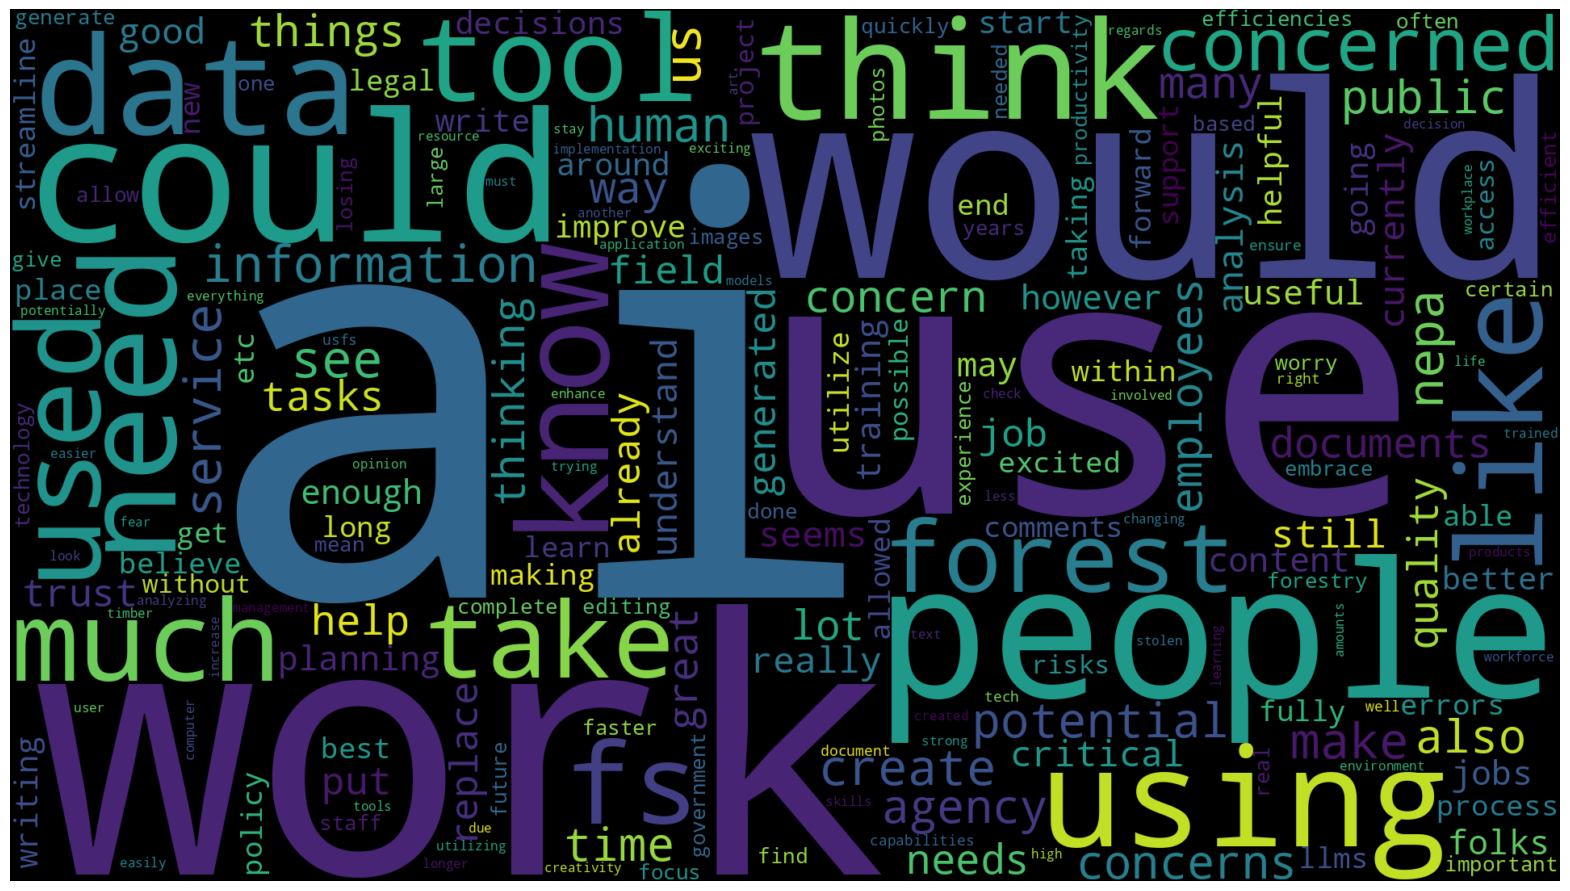

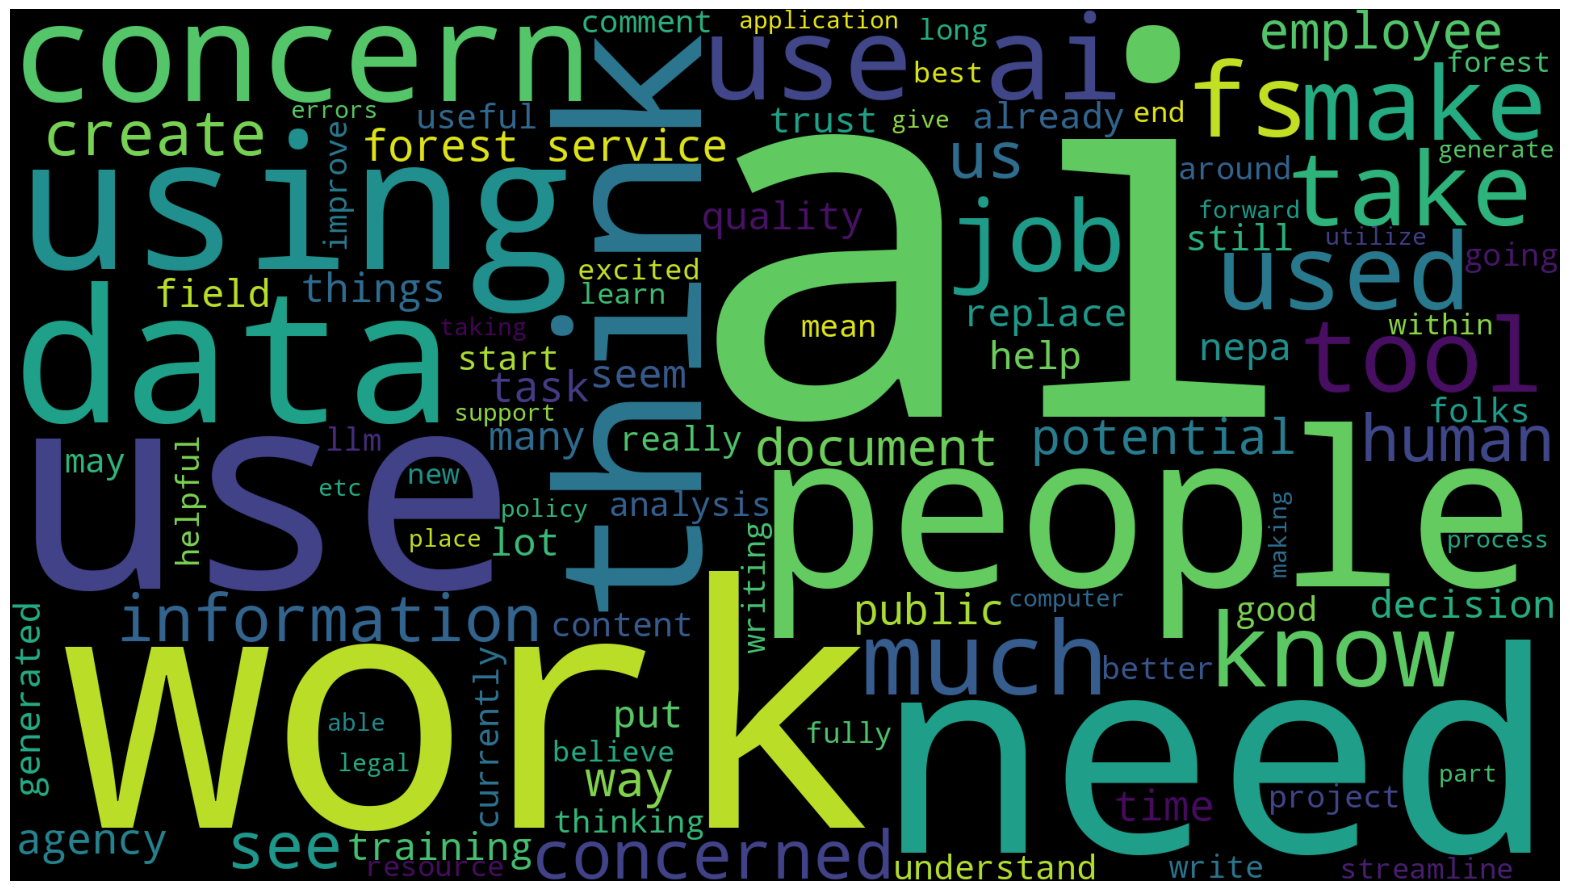

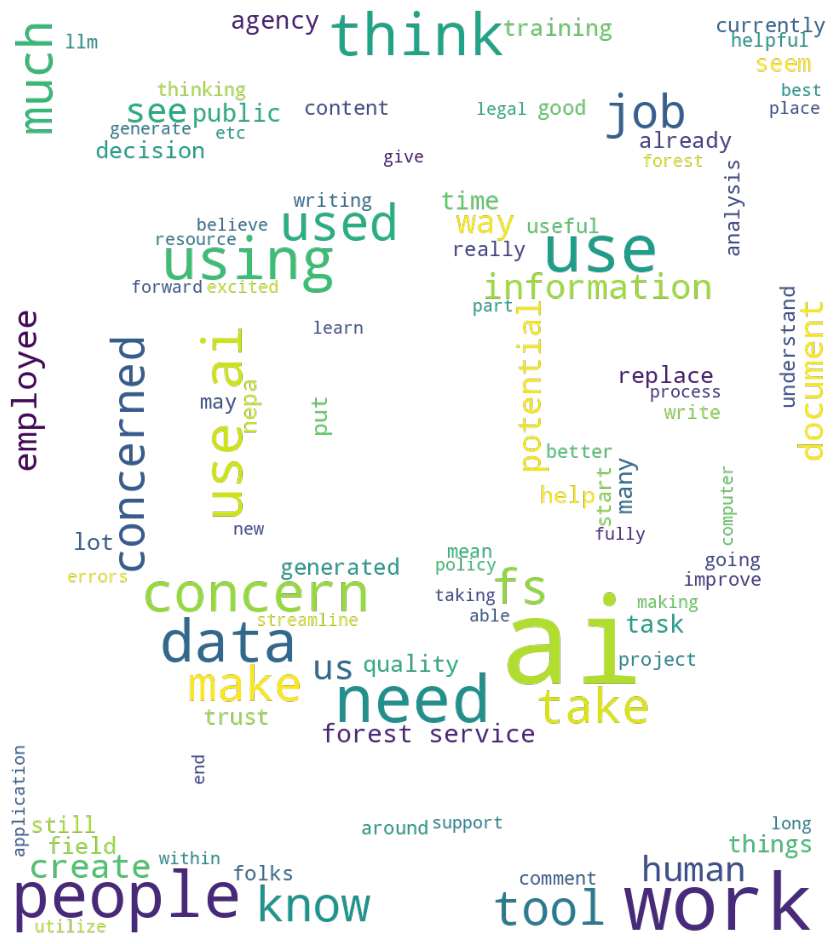

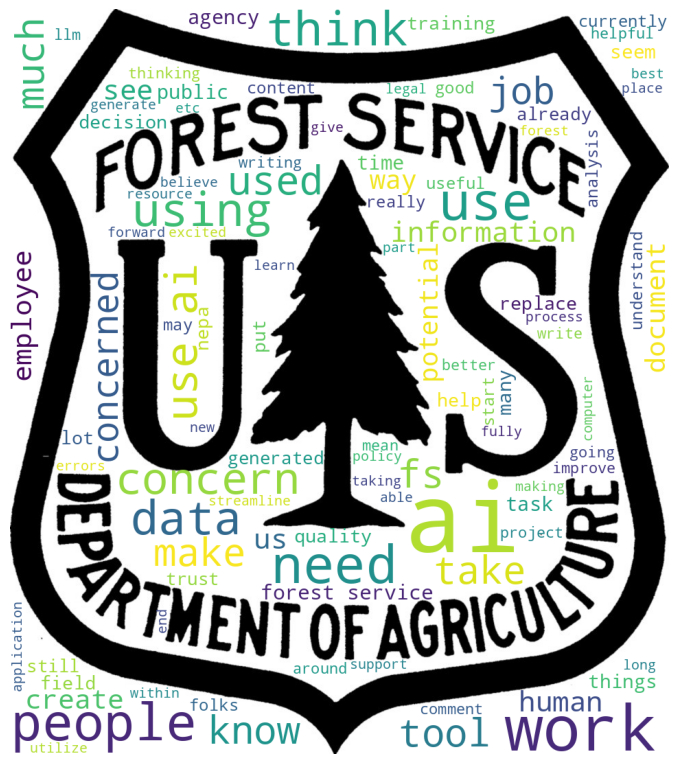

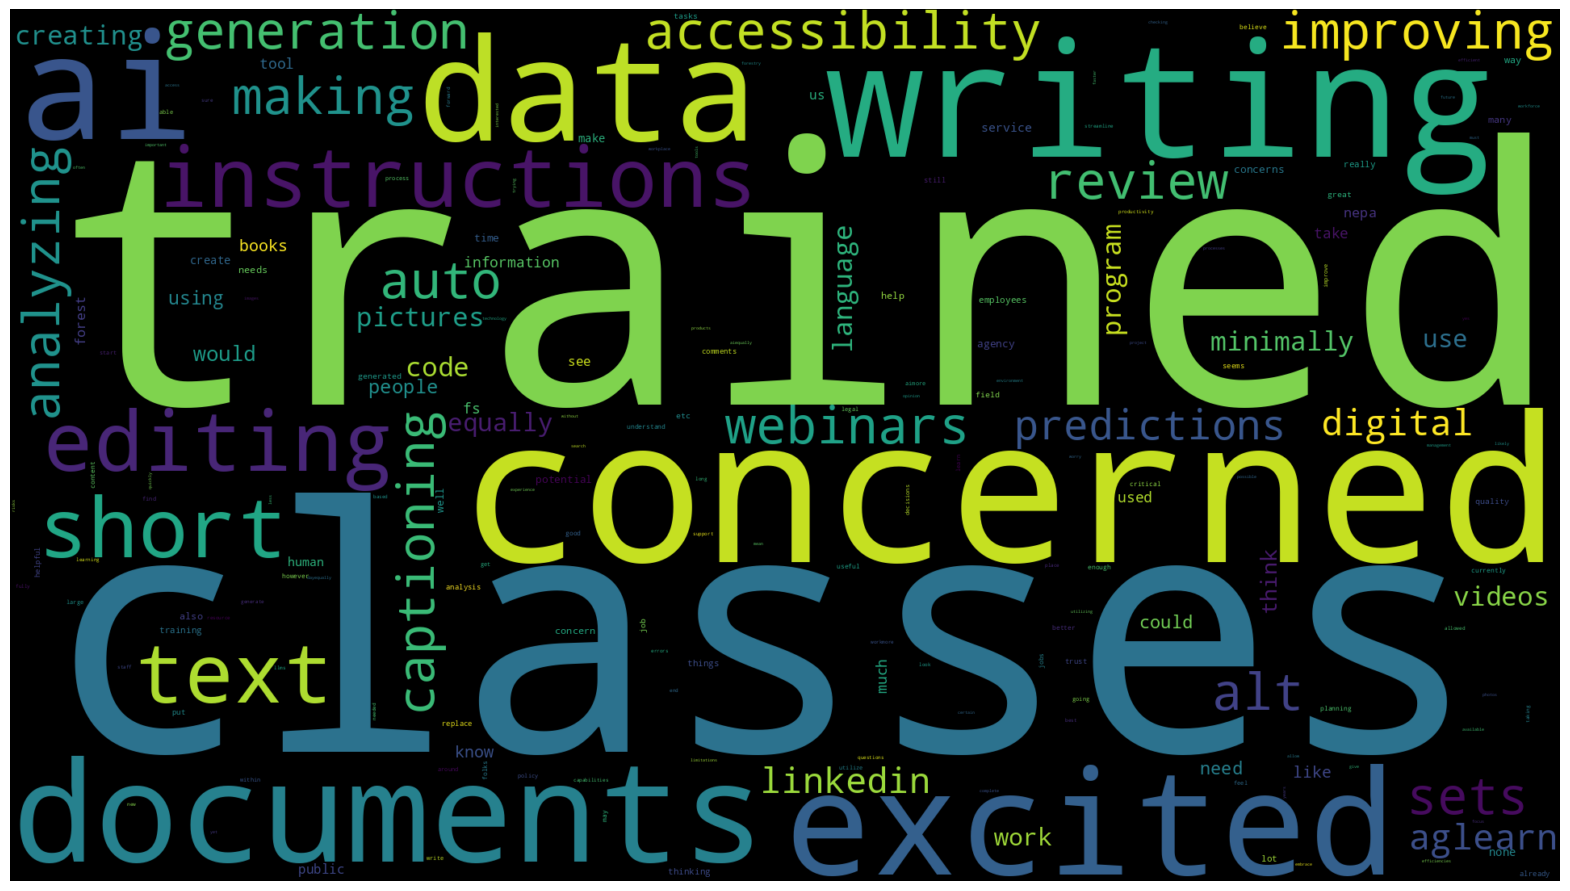

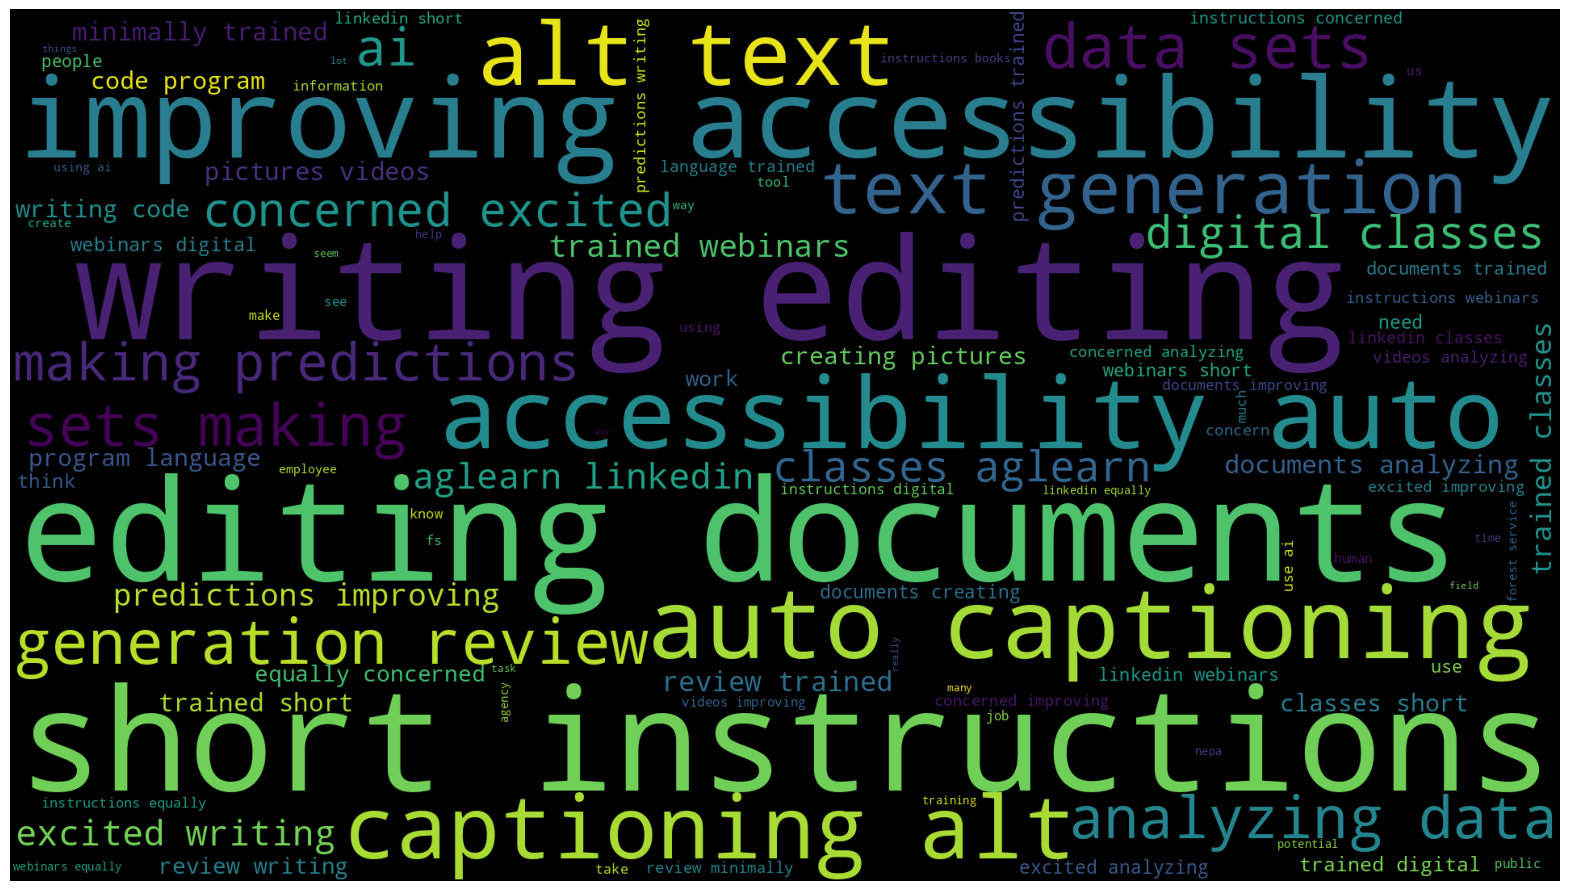

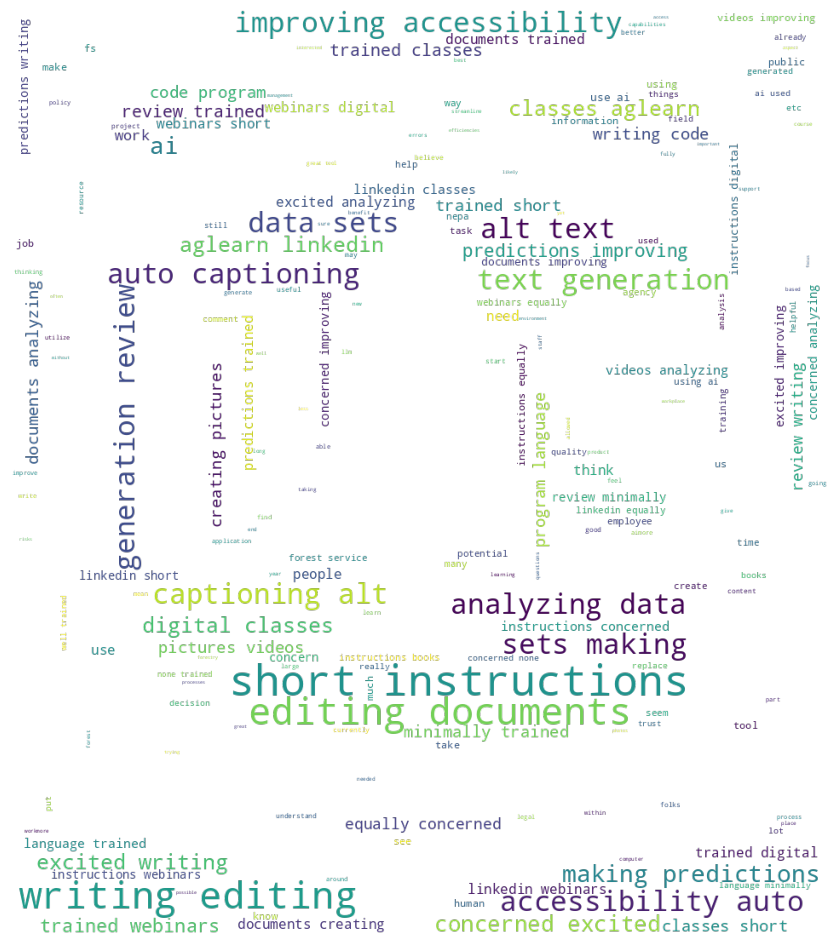

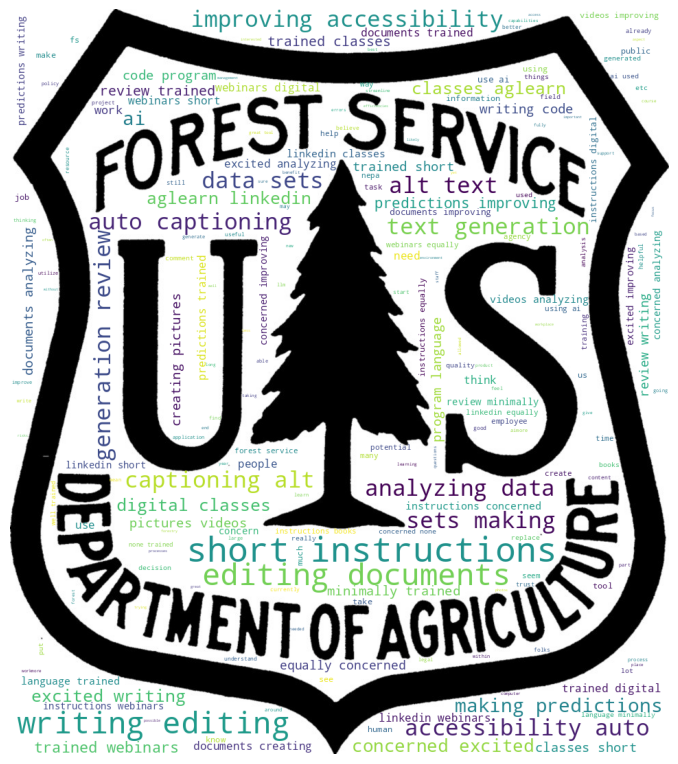

[2024-11-18 18:13:53 UTC]    INFO: Exited __main__ process 
END PROGRAM
Elapsed time: 31.499625687953085


In [290]:
if __name__ == "__main__":

    set_library_configuration()
    start_t=perf_counter()
    print("BEGIN PROGRAM")

    ############################################
    # SECRETS & ENV VARIABLES
    ############################################
    load_dotenv()

    ############################################
    # GLOBAL CONFIGURATION
    ############################################
    #used for values outside standard ASCII, just do it, you'll need it
    ENCODING  ="utf-8"
    os.environ['PYTHONIOENCODING']=ENCODING
    #spacy requirement
    os.environ['TOKENIZERS_PARALLELISM']="false"

    debug.msg_info("Variable declaration.")    
    ############################################
    # GLOBAL VARIABLES
    ############################################
    DEBUG = 1
    DEBUG_DATA = 0
    
    # CODE CONSTRAINTS
    VERSION_NAME    = "slp"
    VERSION_MAJOR   = 0
    VERSION_MINOR   = 7
    VERSION_RELEASE = 0
    
    #used for values outside standard ASCII, just do it, you'll need it
    ENCODING  ="utf-8"
    TEXT_WIDTH=77
    BOLD_START = "\033[1m"
    BOLD_END = "\033[0;0m"
    
    ###########################################
    #- API Parameters for things like WordCloud
    ###########################################
    IMG_BACKGROUND=None                        #None without quotes or "black", "white", etc...
    IMG_FONT_SIZE_MIN=14
    IMG_WIDTH=1920
    IMG_HEIGHT=1080
    
    ############################################
    # APPLICATION VARIABLES
    ############################################
    PROJECT_ID= "usfs-gcp-rand-test-3"
    BUCKET_ID = "usfs-gcp-rand-test3-data-usc1"
    LOCATION = "us-central1"
    SPELL_CHECK_DISTANCE=2
    MINIMUM_AI_WAIT=1                         #seconds
    os.environ["MINIMUM_AI_WAIT"] = "str(MINIMUM_AI_WAIT)"    
    DATA_DIR = f"/home/jupyter/projects/data/{BUCKET_ID}/source_data/nlp/slp"
    OUTPUT_DIR=f"/home/jupyter/projects/data/{BUCKET_ID}/working_data/slp"
    EXCEL_CHAR_BOUNDARY=90
    DELIM="^"
    MAX_WORDS_IN_CLOUD=100
    
    ############################################
    # GENERATIVE MODEL PARAMETERS
    ############################################
    the_model="unknown"
    model_temperature=0.0
    model_max_tokens=0
    model_max_token_response=0
    model_top_p=0.0
    model_frequency_penalty=0
    model_presence_penalty=0
    summary_token_max=0
    if environments[user_input]=="GCP":
        #model parameters
            #Gemini 1.5 Flash	google/gemini-1.5-flash-001 
            #Gemini 1.5 Prov	google/gemini-1.5-pro-001
            #Gemini 1.0 Prov	google/gemini-1.0-pro-002
            #                   google/gemini-1.0-pro-001
            #                   google/gemini-1.0-pro
        #the_model="gemini-1.5-pro-001"
        the_model="gemini-1.5-flash"
        model_temperature=1.0
        model_max_tokens=8000
        model_max_token_response=8000
        model_top_p=0.95
        model_frequency_penalty=0
        model_presence_penalty=0
        summary_token_max=150
    else:
        #model parameters
        the_model="gpt-35-turbo-16k"
        model_temperature=1.0
        model_max_tokens=8000
        model_max_token_response=2000
        model_top_p=0.95
        model_frequency_penalty=0
        model_presence_penalty=0
        summary_token_max=150
    ############################################
    # PROMPT PARAMETERS
    ############################################
    PROMPT_SUMMARY_LIMIT="500"                   #number of words to generate
    PROMPT_SUMMARY_METHOD=" abstractive "        #abstractive or extractive
    PROMPT_INJECTION_MODELS=[
                             #https://python.langchain.com/v0.1/docs/guides/productionization/safety/hugging_face_prompt_injection/
                             #from optimum.onnxruntime import ORTModelForSequenceClassification
                             "protectai/deberta-v3-base-prompt-injection-v2",
                            ]
    #domain gathered from v0.4.0 output summary
    #response_categories = "Job Security, Misinformation, Ethical Concerns, Over-Reliance and Lack of Critical Thinking, Data Quality"
    #add more categories: efficiency/productivity, 
    response_categories = ["Efficiency and Automation", "Training and Governance", "Job Displacement and Impact on Human Roles", "Data Quality, Accuracy, and Bias", "Ethical Considerations and Responsible Use"]
    
    JSON_PAYLOAD = '{ \
      "Sentiment": 0.0 \
      "SentimentConfidence": 0.0, \
      "Category": "Some Category", \
    }'
    
    JSON_ERROR = ' { \
        "Sentiment": -999.0, \
        "SentimentConfidence": -999.0, \
        "Category": "error", \
    }'
    
    EXAMPLE_JSON = '{ \
      "Sentiment": -0.5, \
      "SentimentConfidence": 0.8, \
      "Category": "Data Quality", \
    }'
    
    ########################################
    #Define Potential "answers" from the various neural layers
    #Is the Prompt Detected?
    ########################################
    id2label = {
        'LEGIT':    False,
        'POSITIVE': False,
        'LABEL_1':  False,
        'SAFE':     False,
        
        'INJECTION':True,
        'NEGATIVE': True,
        'LABEL_0':  True,
        'UNSAFE':   True,
    }
    prompt_defense_model_chunk_size=512

    ########################################
    #Safety filter settings for Google GenAI
    ########################################
    safety_settings = [
      {
        "category": "HARM_CATEGORY_HARASSMENT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_HATE_SPEECH",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_SEXUALLY_EXPLICIT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
      {
        "category": "HARM_CATEGORY_DANGEROUS_CONTENT",
        "threshold": "BLOCK_MEDIUM_AND_ABOVE",
      },
    ]    
    ############################################
    # NLTK instantiation
    ############################################
    debug.msg_debug(f"...StopWords instantiated.")
    stop_words = set(stopwords.words("english"))
    debug.msg_debug(f"...PortStemmer instantiated.")
    stemmer = PorterStemmer()
    debug.msg_debug(f"...Lemmatizer instantiated.")
    lemmatizer = WordNetLemmatizer()
    
    #setup the text wrapper
    debug.msg_debug(f"...Text Wrapper instantiated.")
    wrapper = textwrap.TextWrapper(width=TEXT_WIDTH)
    
    #show your libraries
    lib_diagnostics()

    ###########################################
    #- OPENAI
    # Generative AI Library Configuration
    # Tailored for OpenAI environment on Azure for now.  API keys and other relevant information in .bashrc_keys environment variable on system for security.
    ###########################################
    if environments[user_input]=="GCP":
        debug.msg_info("GCP GenAI setup")
        client=setup_gcpgenai_client()
    else:
        debug.msg_info("OPENAI setup")
        client=setup_openai_client()
    

    ###########################################
    #- Workhorse routine
    ###########################################
    process()
    
    end_t=perf_counter()
    print("END PROGRAM")
    print(f"Elapsed time: {end_t - start_t}")
